This template is used to read LOGR Solar measurement files using nrgpy. It can handle statistical or one-second files.

In [21]:
import nrgpy
import pandas as pd

from se_analysis import channel_names, parse_site_info, project, rename_channels, read_files
from se_analysis.plot import plot_signals

pd.set_option("display.max_rows", 50)      # or None for unlimited


Here is an example of reading a single one-second file.

In [22]:
file_name = project("SRM", "Keene-Branch_FL", "MET1", "20260821_1217_003209_000022_onesecond.dat")
reader = nrgpy.LogrRead(filename=file_name)

In [23]:
reader.Site_info

,0,1
0,Model Number:,9432
1,Serial Number:,3209
2,Created FW Version:,1.13.06
3,Site Properties,NaN
4,Site:,3209
...,...,...
240,Serial Number:,179500409593
241,Scale Factor:,0.765000
242,Offset:,0.350000
243,Height:,0.00


Here is an example of reading all statistical .dat files in a directory. The error shown below is due to a bug in nrgpy; you can ignore it.

In [27]:
data_dir = project("SRM", "Keene-Branch_FL", "MET2")
reader = read_files(data_dir, file_type="statistical")

2026-09-09 08:04:08,506 | INFO | [logr:559] | Concatenating 4 files...


Time elapsed: 0 s | 4  / 4  [=============================================] 100%	

2026-09-09 08:04:08,624 | ERROR | [logr:661] | could not sort ch_info
Traceback (most recent call last):
  File "c:\Users\bftro\code\se-analyis\.venv\Lib\site-packages\nrgpy\read\logr.py", line 658, in concat_txt
    .drop(columns=["ch", "Channel"], axis=1, errors="ignore")
     ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\bftro\code\se-analyis\.venv\Lib\site-packages\pandas\core\frame.py", line 6302, in drop
    return super().drop(
           ~~~~~~~~~~~~^
        labels=labels,
        ^^^^^^^^^^^^^^
    ...<5 lines>...
        errors=errors,
        ^^^^^^^^^^^^^^
    )
    ^
  File "c:\Users\bftro\code\se-analyis\.venv\Lib\site-packages\pandas\core\generic.py", line 4619, in drop
    raise ValueError("Cannot specify both 'axis' and 'index'/'columns'")
ValueError: Cannot specify both 'axis' and 'index'/'columns'
2026-09-09 08:04:08,650 | INFO | [logr:677] | Concatenation of 112 rows complete


`reader.Site_info` returns a DataFrame. `parse_site_info` turns that into a dictionary that's more convenient to use.

In [28]:
site_info = parse_site_info(reader.Site_info)
site_info

{'Model Number': '9432',
 'Serial Number': '000000000',
 'Created FW Version': '1.13.06',
 'Site Properties': nan,
 'Site': '3179',
 'Project': 'Keene Branch,FL',
 'Location': 'INV-1401',
 'Latitude': '27.67011',
 'Longitude': '-82.26567',
 'Elevation': '19',
 'Time Zone': '-5',
 'File Properties': nan,
 'File Schema Version': '1',
 'SD Card Free Space (kB)': '8027111',
 'FTP FW Version': '1.13.06',
 'File Content': 'Statistics',
 'Configuration Version': '5',
 'Statistical Interval (min)': '1',
 'Sensor History': nan,
 'Channel': '404',
 'Description': 'Rainwise TBRG',
 'Units': 'mm',
 'Scale Factor': '0.254000',
 'Offset': '0.000000',
 'Height': '0.00',
 'Boom Bearing': '0.0',
 'Vane Mounting Angle': '180.0',
 'Gust Source Channel': '403',
 'Client ID': '2',
 'Sensor Type': 'Hukseflux SR300',
 'Measurand': 'Internal Pressure'}

In [29]:
df = reader.data
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.set_index("Timestamp").sort_index()
df

,Ch1_Avg_deg_C,Ch1_Min_deg_C,Ch1_Max_deg_C,Ch1_SD_deg_C,Ch1_NotUsed,Ch3_Avg_deg_C,Ch3_Min_deg_C,Ch3_Max_deg_C,Ch3_SD_deg_C,Ch3_NotUsed,...,Ch403_Avg_m/s,Ch403_Min_m/s,Ch403_Max_m/s,Ch403_SD_m/s,Ch403_Gust_m/s,Ch404_Avg_mm,Ch404_Min_mm,Ch404_Max_mm,Ch404_SD_mm,Ch404_Total_mm
Timestamp,,,,,,,,,,,,,,,,,,,,,
2026-08-21 14:25:00+00:00,48.5695,48.4568,48.746,0.0901,0.0,47.6172,47.5329,47.7533,0.0663,0.0,...,0.35,0.35,0.35,0.0,0.35,0.0,0.0,0.0,0.0,0.0
2026-08-21 14:26:00+00:00,48.2282,48.0325,48.4455,0.1145,0.0,47.2962,47.0418,47.5308,0.152,0.0,...,1.1532,0.35,2.645,0.6046,2.135,0.0,0.0,0.0,0.0,0.0
2026-08-21 14:27:00+00:00,47.6887,47.3103,48.029,0.2416,0.0,46.7352,46.3629,47.0454,0.2313,0.0,...,1.0768,0.35,2.645,0.6519,2.135,0.0,0.0,0.0,0.0,0.0
2026-08-21 14:28:00+00:00,47.1114,46.9925,47.304,0.1027,0.0,46.1506,46.0351,46.3591,0.1095,0.0,...,1.166,0.35,1.88,0.5052,1.88,0.0,0.0,0.0,0.0,0.0
2026-08-21 14:29:00+00:00,47.3625,47.0462,47.7237,0.2051,0.0,46.4256,46.0709,46.8338,0.241,0.0,...,1.574,0.35,2.645,0.5308,2.39,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-21 16:12:00+00:00,57.9947,57.8921,58.2437,0.1028,0.0,56.9725,56.8508,57.2517,0.1185,0.0,...,1.0385,0.35,1.88,0.3646,1.37,0.0,0.0,0.0,0.0,0.0
2026-08-21 16:13:00+00:00,58.6815,58.2596,59.1508,0.2644,0.0,57.7849,57.271,58.3293,0.3227,0.0,...,0.5667,0.35,1.115,0.3476,1.115,0.0,0.0,0.0,0.0,0.0
2026-08-21 16:14:00+00:00,59.5755,59.1629,59.9051,0.2256,0.0,58.7918,58.3484,59.1156,0.236,0.0,...,0.8855,0.35,1.88,0.5137,1.625,0.0,0.0,0.0,0.0,0.0


`channel_names` returns a dictionary that maps the channel number to a more descriptive name.

In [34]:
names = channel_names(reader.Site_info)
names

{'1': 'Ch1_Pt1000_deg_C',
 '3': 'Ch3_Pt1000_deg_C',
 '5': 'Ch5_Pt1000_deg_C',
 '7': 'Ch7_NRG_Grid_Monitor_(0_to_30)V_V',
 '11': 'Ch11_NRG_200M_Vane_Deg',
 '12': 'Ch12_NRG_RH5X_%',
 '13': 'Ch13_NRG_BP65_hPa',
 '14': 'Ch14_NRG_T60_deg_C',
 '101': 'Ch101_Hukseflux_SR300-GHI_Temp_Compensated_Irradiance_W/m^2',
 '102': 'Ch102_Hukseflux_SR300-GHI_Instrument_Temperature_deg_C',
 '103': 'Ch103_Hukseflux_SR300-GHI_Internal_Relative_Humidity_%',
 '104': 'Ch104_Hukseflux_SR300-GHI_Tilt_deg',
 '105': 'Ch105_Hukseflux_SR300-GHI_Fan_RPM_RPM',
 '106': 'Ch106_Hukseflux_SR300-GHI_Heater_Current_mA',
 '107': 'Ch107_Hukseflux_SR300-GHI_Internal_Pressure_hPa',
 '108': 'Ch108_Kipp_&_Zonen_DustIQ_Soiling_1_%',
 '109': 'Ch109_Kipp_&_Zonen_DustIQ_Soiling_2_%',
 '110': 'Ch110_Kipp_&_Zonen_DustIQ_Tilt_X_deg',
 '111': 'Ch111_Kipp_&_Zonen_DustIQ_Tilt_Y_deg',
 '112': 'Ch112_Kipp_&_Zonen_DustIQ_BOP_Temp_deg_C',
 '113': 'Ch113_Hukseflux_SR300-POA_Temp_Compensated_Irradiance_W/m^2',
 '114': 'Ch114_Hukseflux_SR300-POA

The `names` dictionary is then used to rename the columns in the DataFrame.

In [31]:
df = rename_channels(df, names)
df

,Ch1_Avg_Pt1000_deg_C,Ch1_Min_Pt1000_deg_C,Ch1_Max_Pt1000_deg_C,Ch1_SD_Pt1000_deg_C,Ch3_Avg_Pt1000_deg_C,Ch3_Min_Pt1000_deg_C,Ch3_Max_Pt1000_deg_C,Ch3_SD_Pt1000_deg_C,Ch5_Avg_Pt1000_deg_C,Ch5_Min_Pt1000_deg_C,...,Ch403_Avg_NRG_40_Anemometer_m/s,Ch403_Min_NRG_40_Anemometer_m/s,Ch403_Max_NRG_40_Anemometer_m/s,Ch403_SD_NRG_40_Anemometer_m/s,Ch403_Gust_NRG_40_Anemometer_m/s,Ch404_Avg_Rainwise_TBRG_mm,Ch404_Min_Rainwise_TBRG_mm,Ch404_Max_Rainwise_TBRG_mm,Ch404_SD_Rainwise_TBRG_mm,Ch404_Total_Rainwise_TBRG_mm
Timestamp,,,,,,,,,,,,,,,,,,,,,
2026-08-21 14:25:00+00:00,48.5695,48.4568,48.746,0.0901,47.6172,47.5329,47.7533,0.0663,47.271,47.1741,...,0.35,0.35,0.35,0.0,0.35,0.0,0.0,0.0,0.0,0.0
2026-08-21 14:26:00+00:00,48.2282,48.0325,48.4455,0.1145,47.2962,47.0418,47.5308,0.152,46.9197,46.6829,...,1.1532,0.35,2.645,0.6046,2.135,0.0,0.0,0.0,0.0,0.0
2026-08-21 14:27:00+00:00,47.6887,47.3103,48.029,0.2416,46.7352,46.3629,47.0454,0.2313,46.4183,46.0899,...,1.0768,0.35,2.645,0.6519,2.135,0.0,0.0,0.0,0.0,0.0
2026-08-21 14:28:00+00:00,47.1114,46.9925,47.304,0.1027,46.1506,46.0351,46.3591,0.1095,45.8714,45.7478,...,1.166,0.35,1.88,0.5052,1.88,0.0,0.0,0.0,0.0,0.0
2026-08-21 14:29:00+00:00,47.3625,47.0462,47.7237,0.2051,46.4256,46.0709,46.8338,0.241,46.0497,45.7484,...,1.574,0.35,2.645,0.5308,2.39,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-21 16:12:00+00:00,57.9947,57.8921,58.2437,0.1028,56.9725,56.8508,57.2517,0.1185,57.1638,56.9414,...,1.0385,0.35,1.88,0.3646,1.37,0.0,0.0,0.0,0.0,0.0
2026-08-21 16:13:00+00:00,58.6815,58.2596,59.1508,0.2644,57.7849,57.271,58.3293,0.3227,57.9319,57.492,...,0.5667,0.35,1.115,0.3476,1.115,0.0,0.0,0.0,0.0,0.0
2026-08-21 16:14:00+00:00,59.5755,59.1629,59.9051,0.2256,58.7918,58.3484,59.1156,0.236,58.6997,58.3903,...,0.8855,0.35,1.88,0.5137,1.625,0.0,0.0,0.0,0.0,0.0


Plot each signal in the DataFrame grouping the statistics together. The SD is shown on a different axis because it usually has a very different scale than the signal.

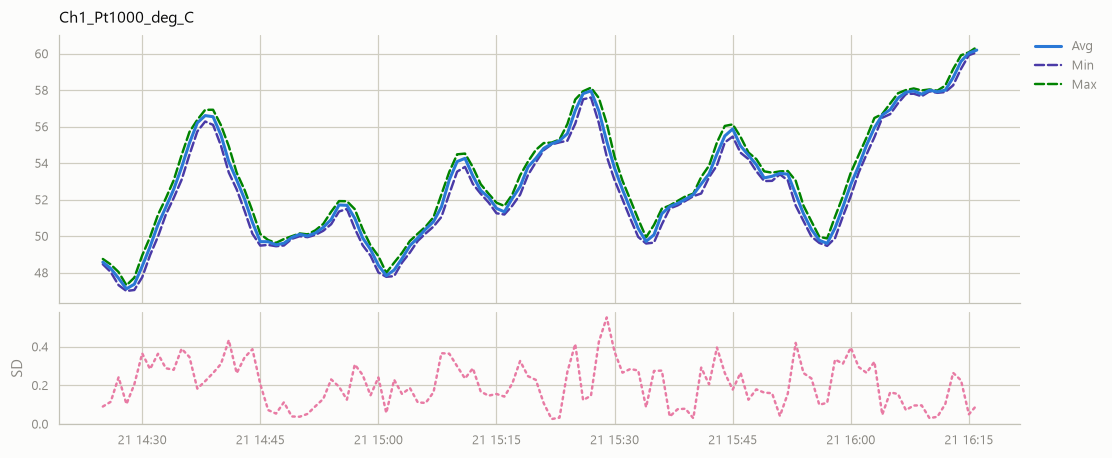

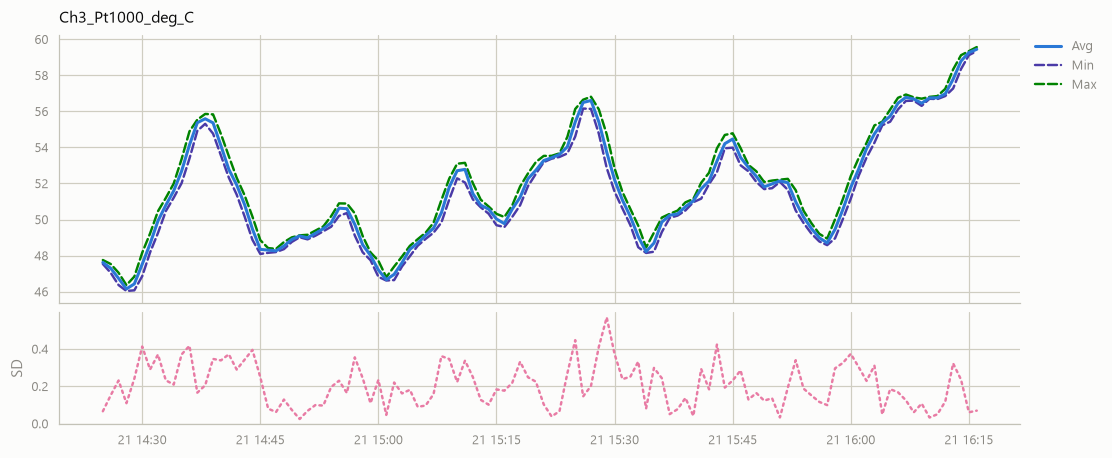

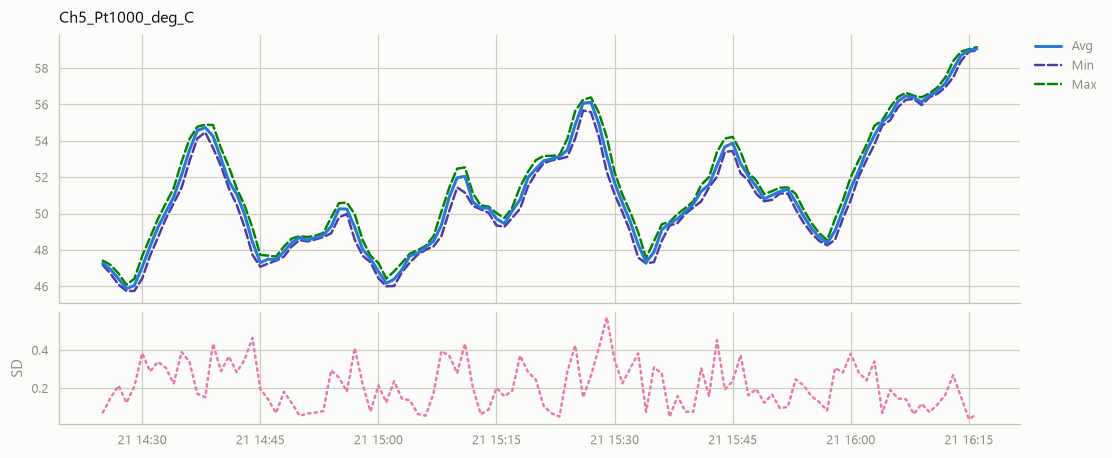

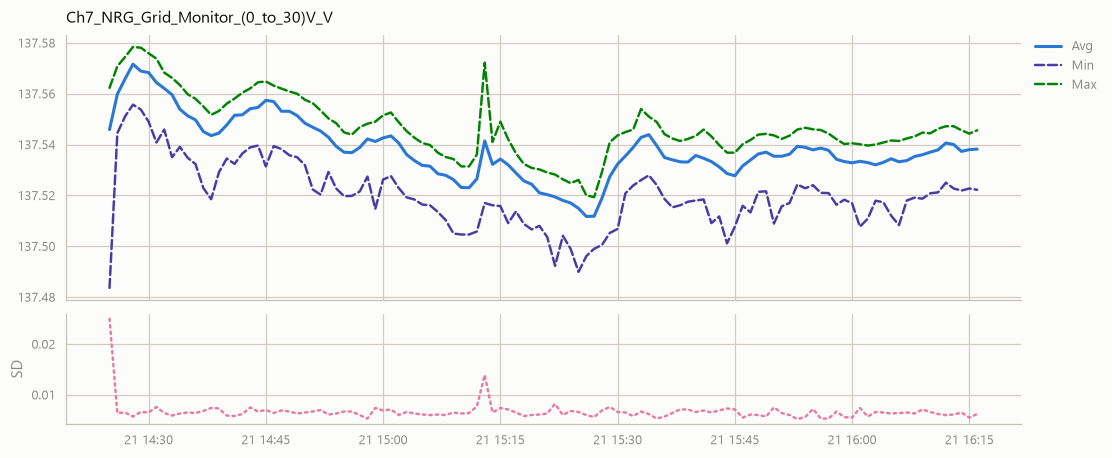

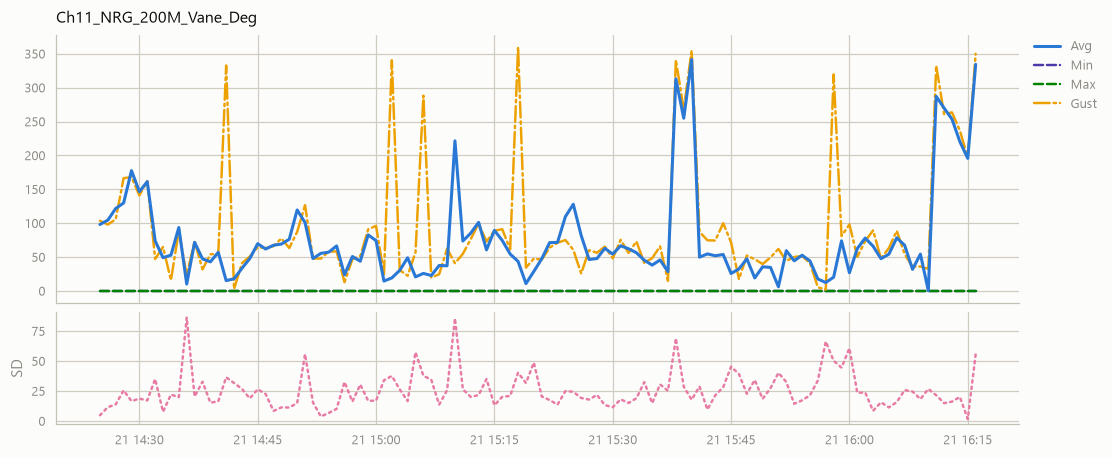

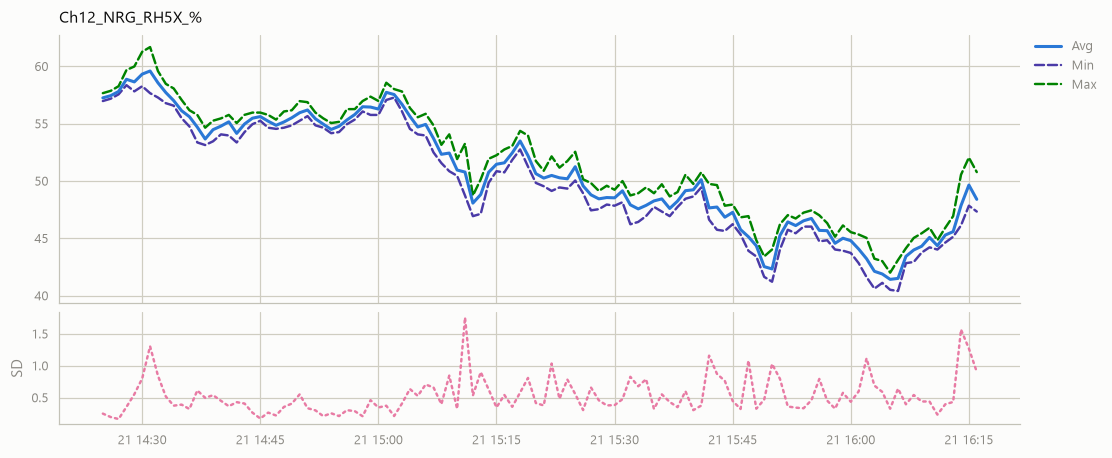

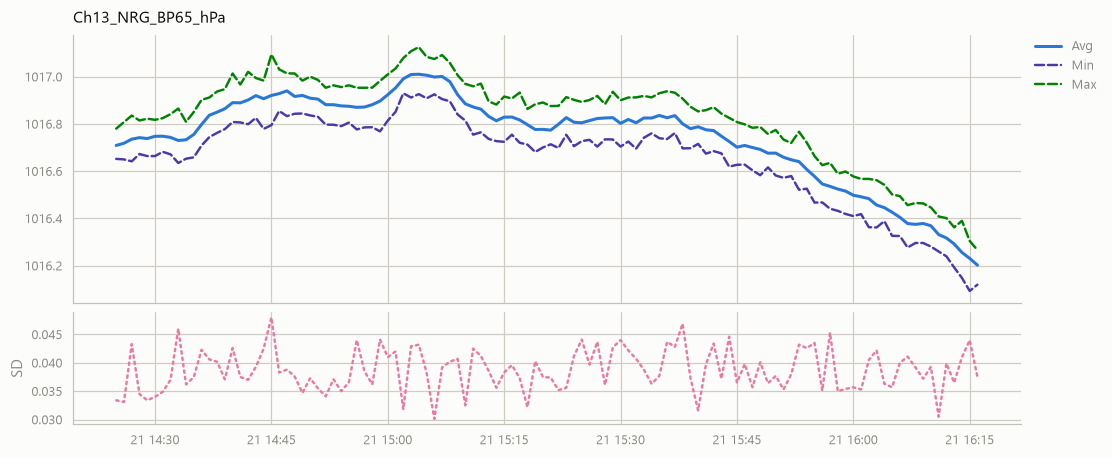

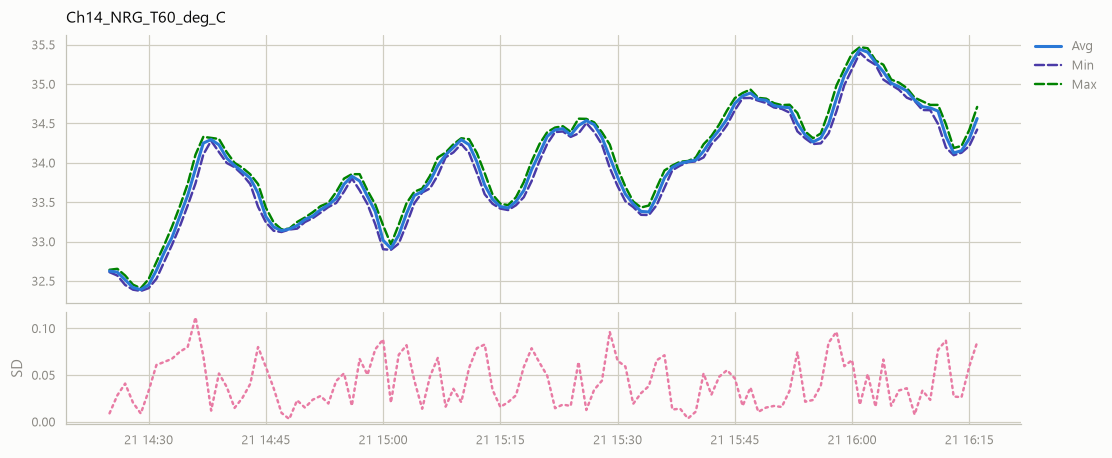

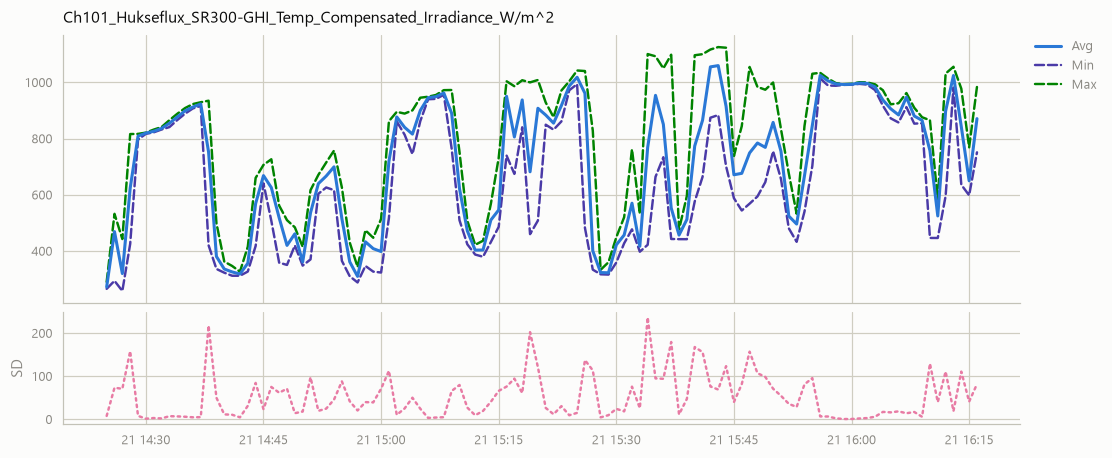

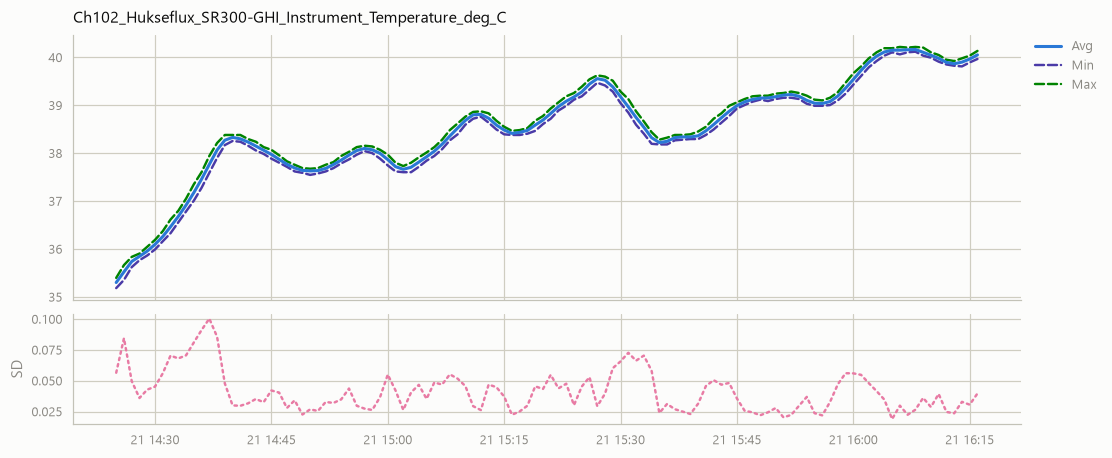

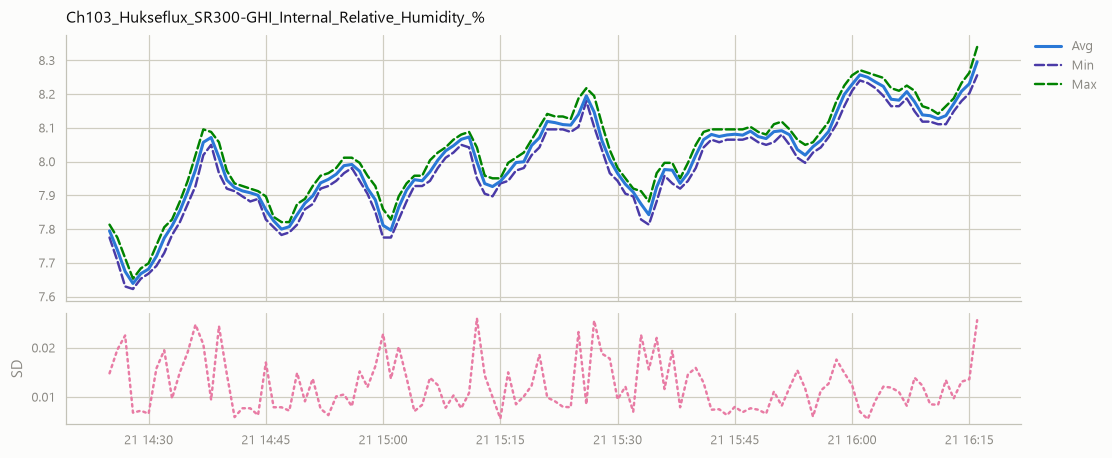

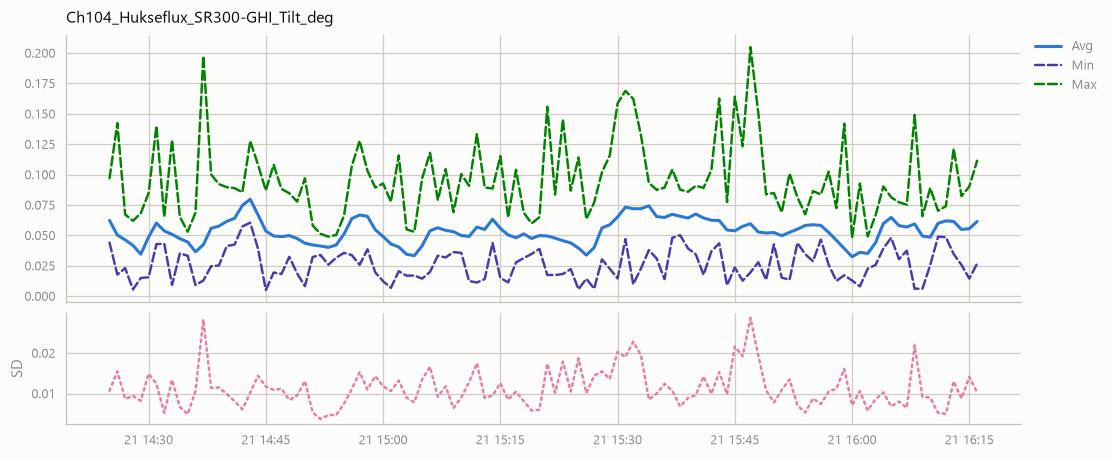

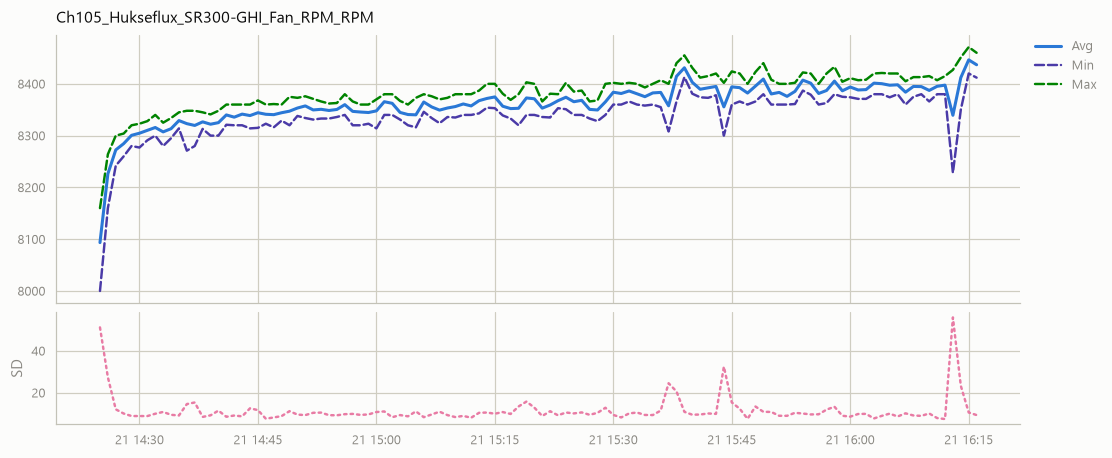

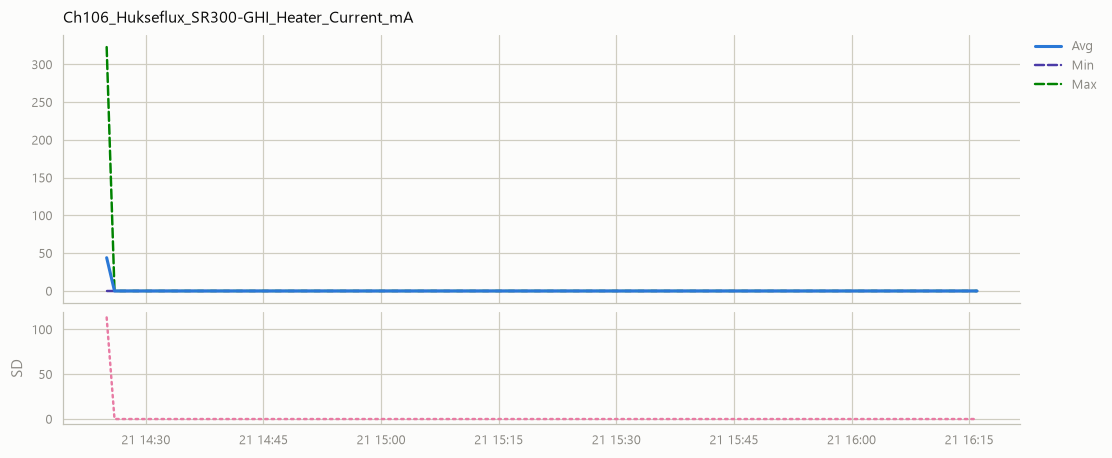

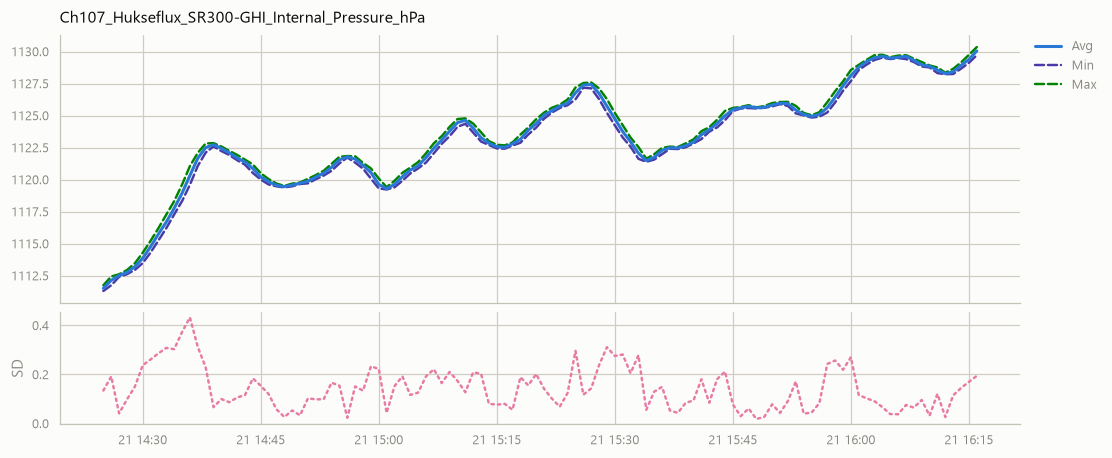

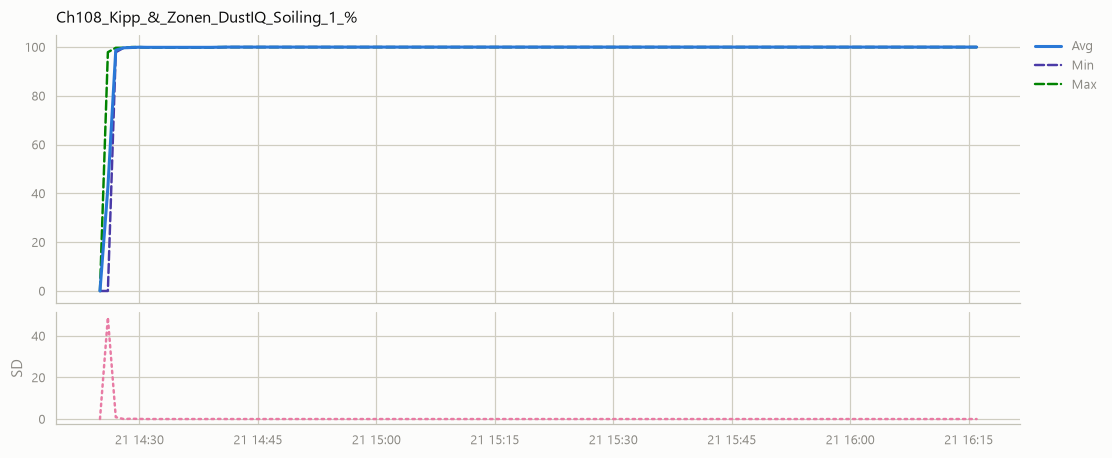

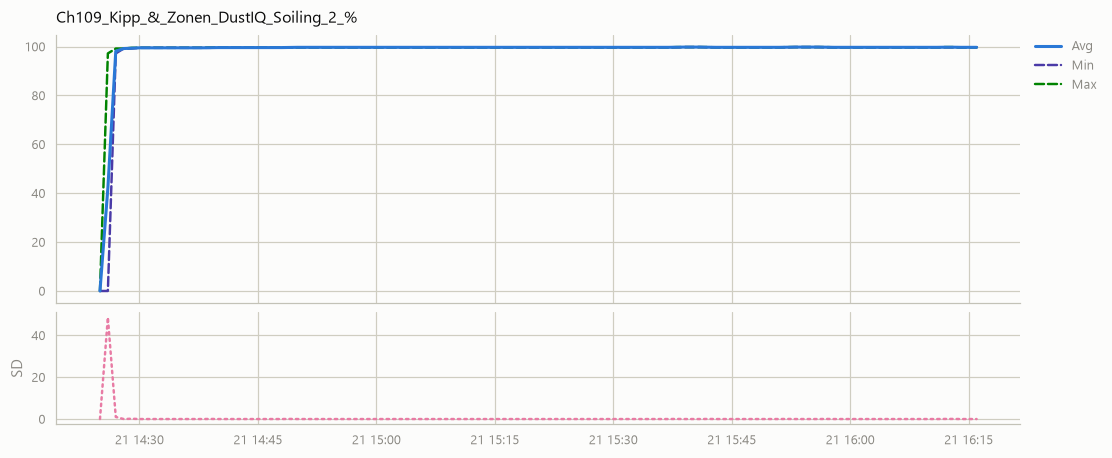

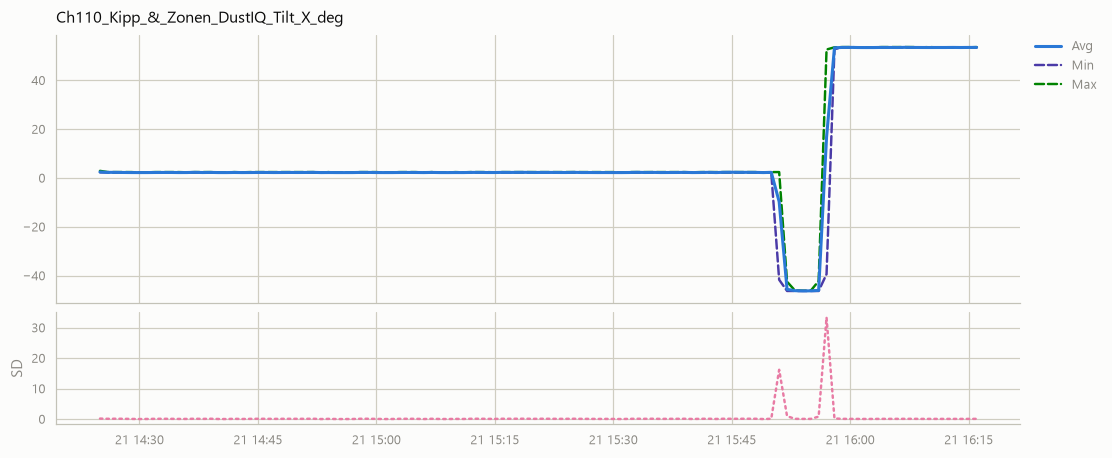

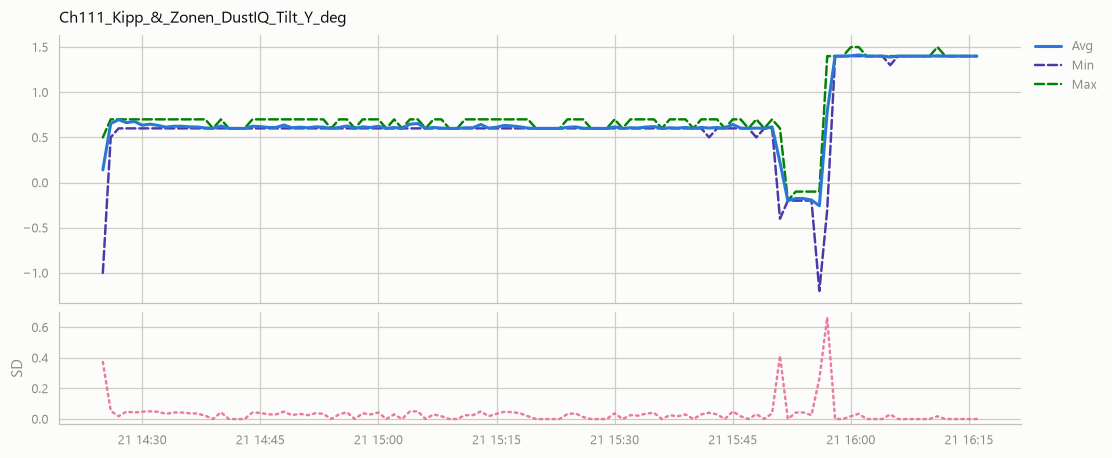

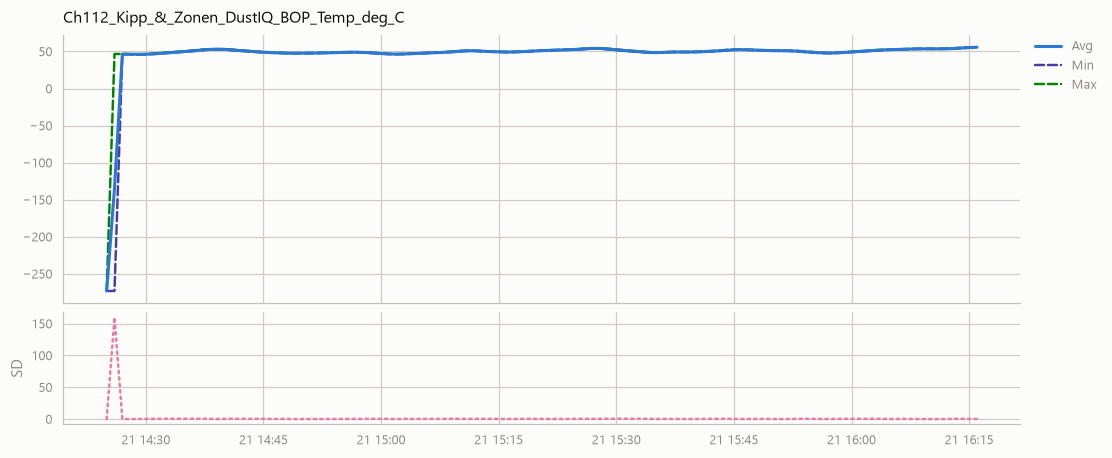

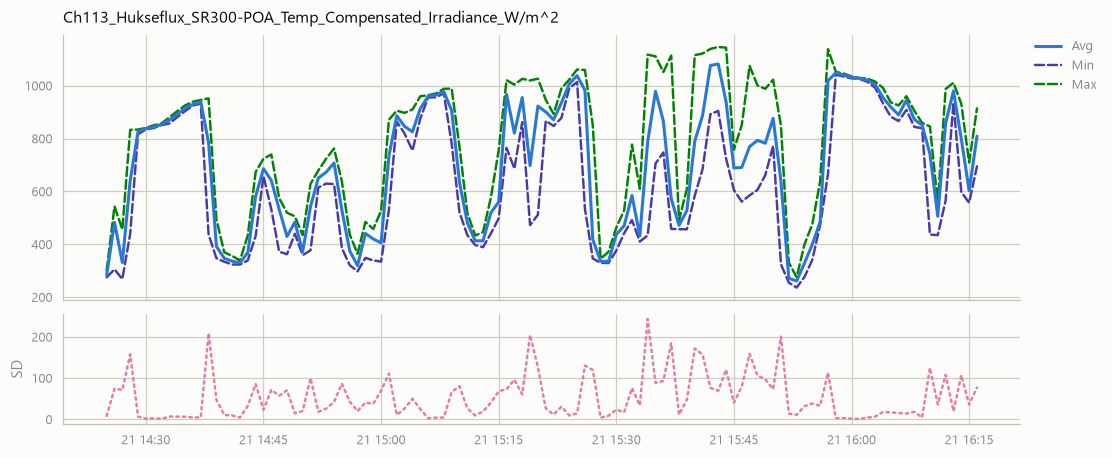

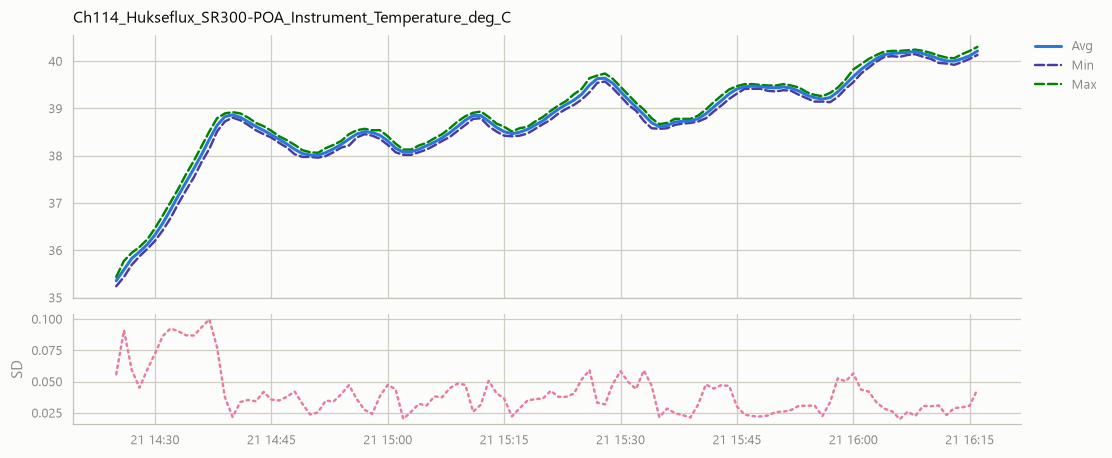

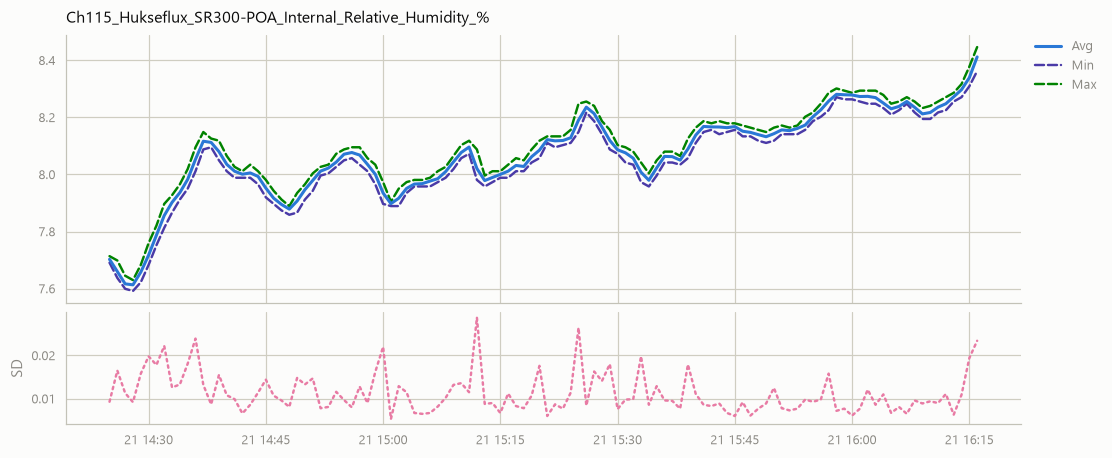

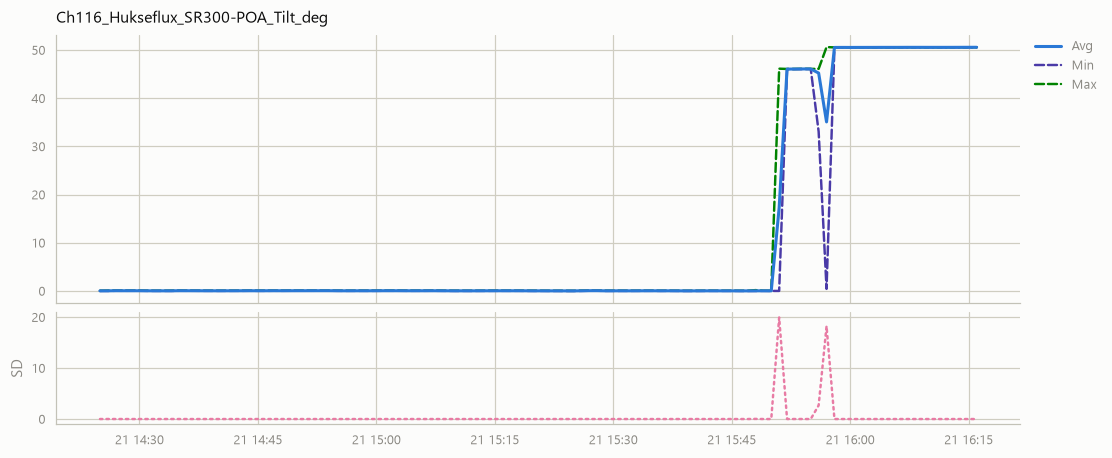

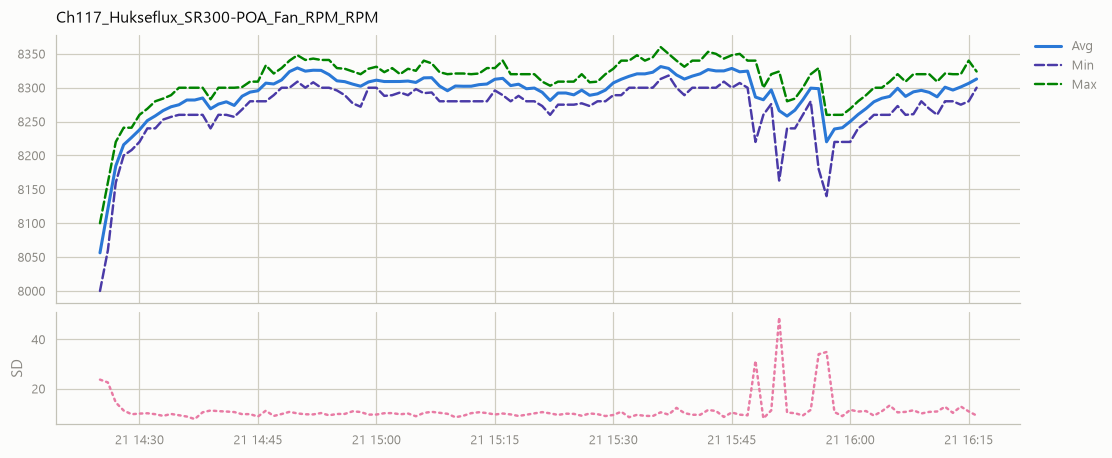

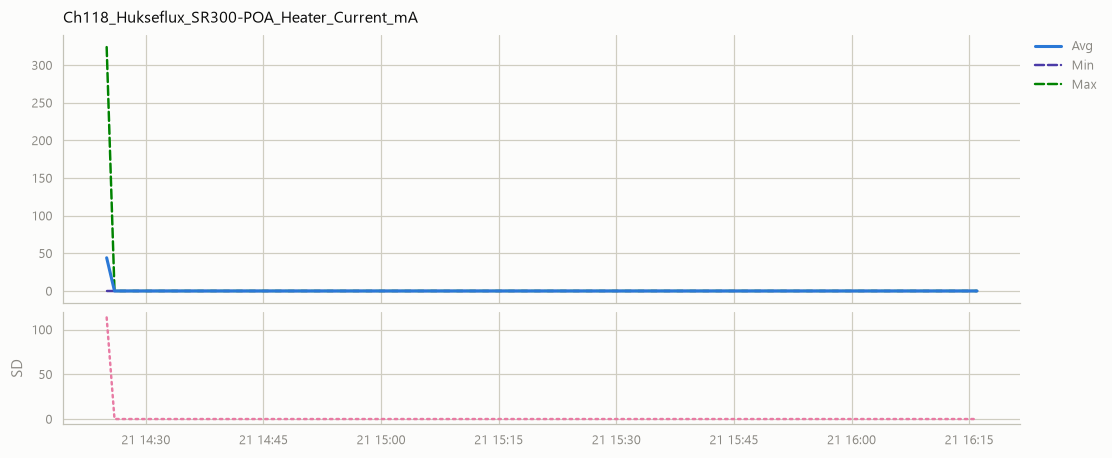

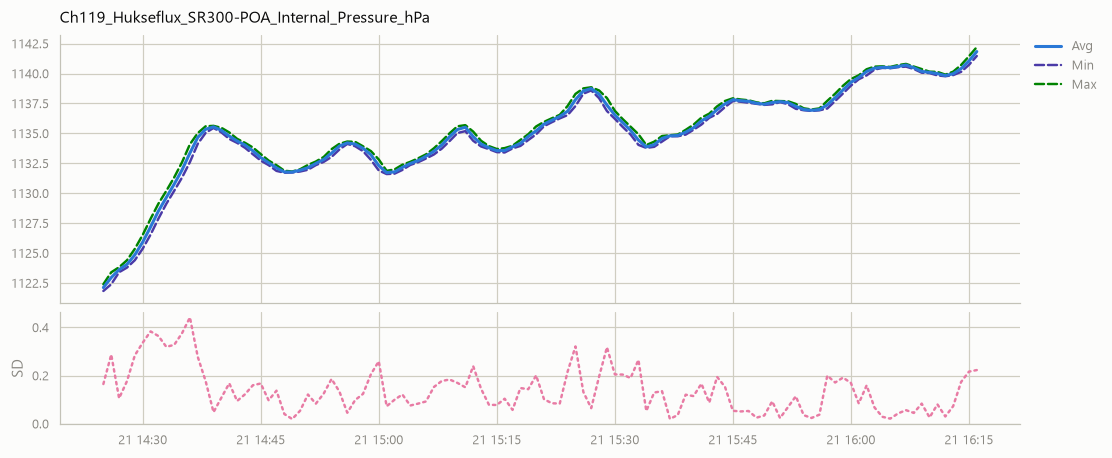

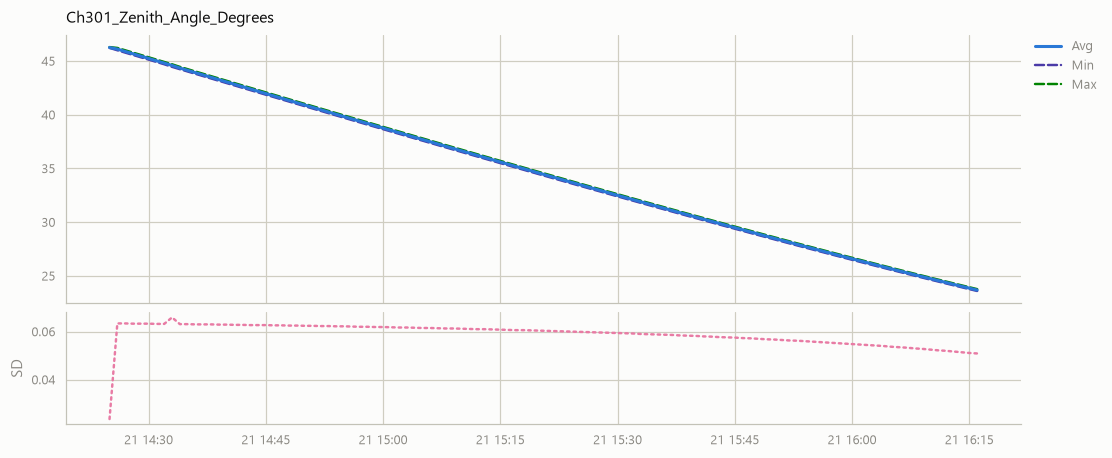

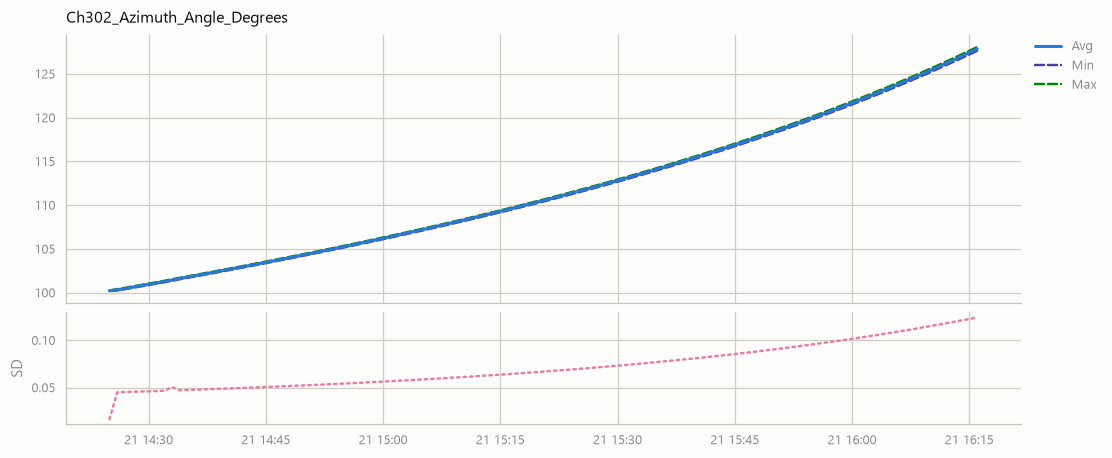

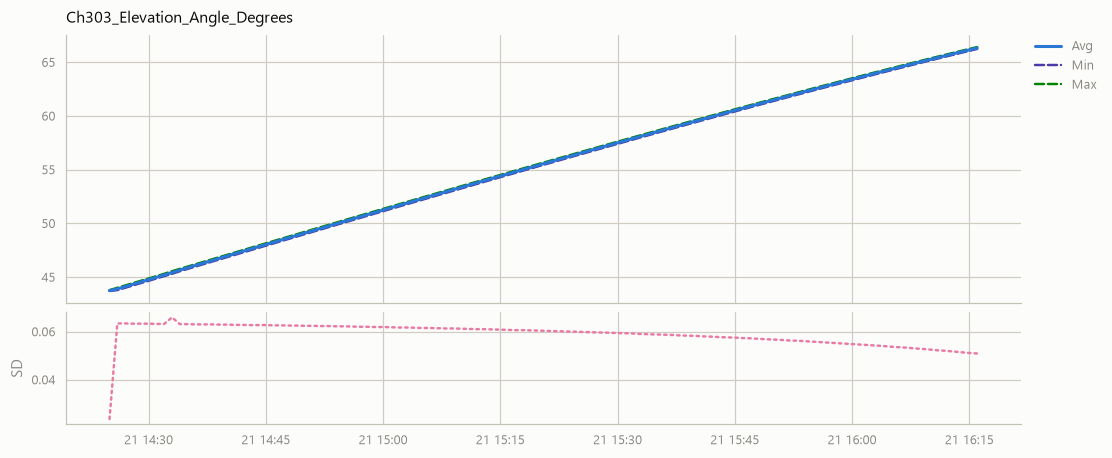

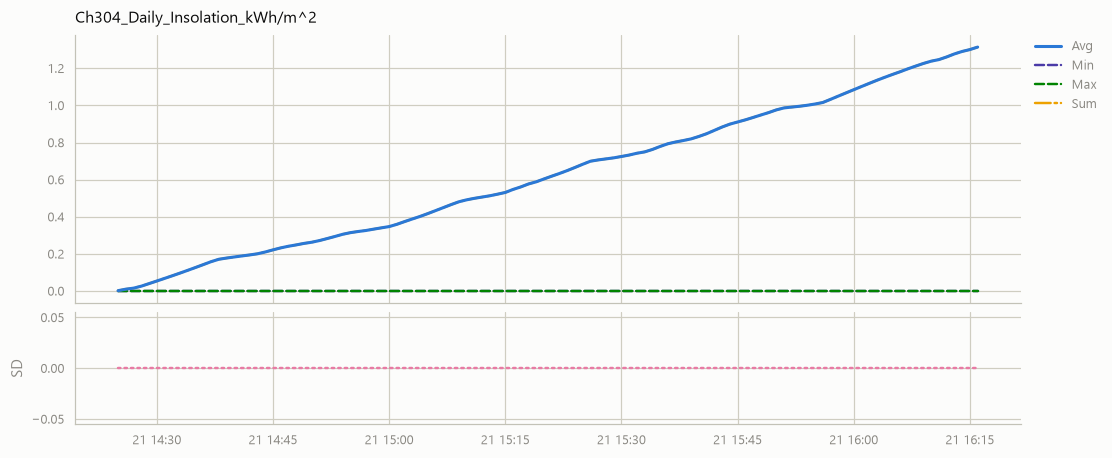

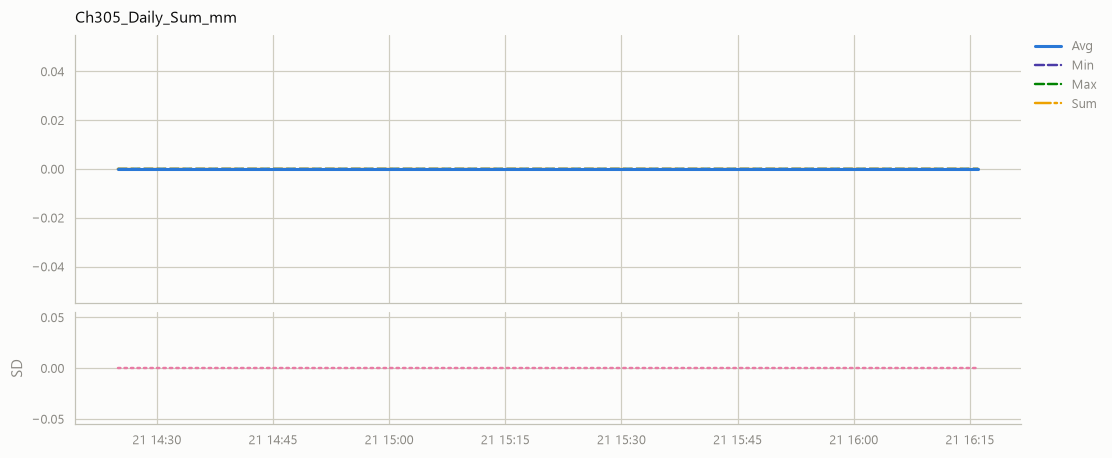

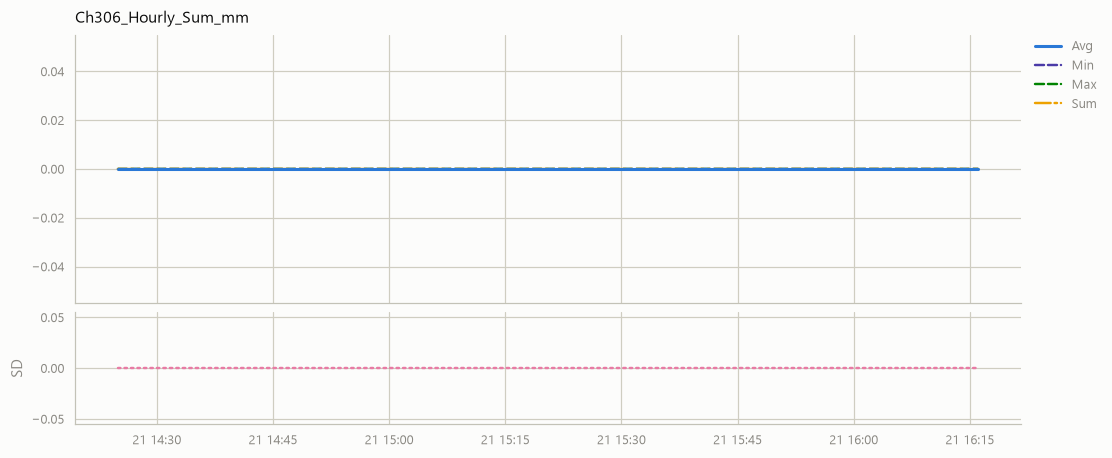

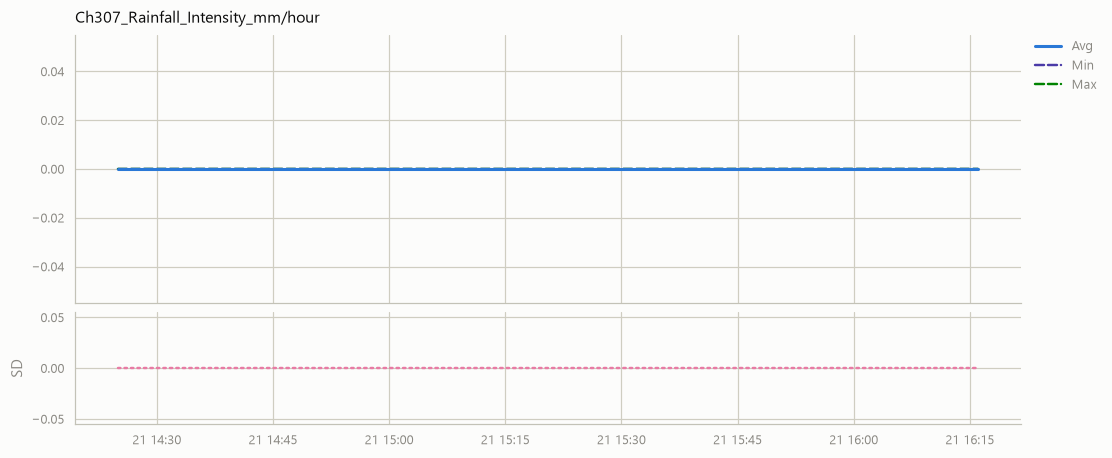

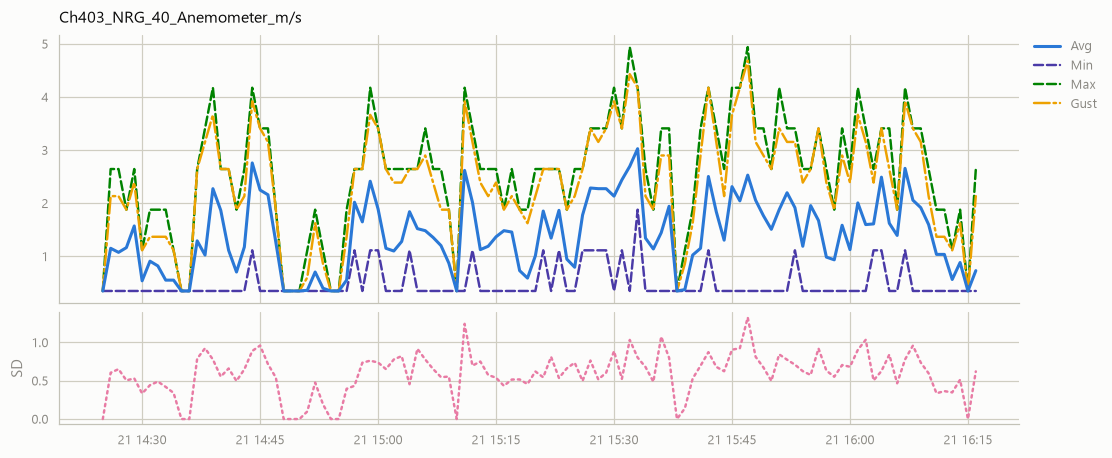

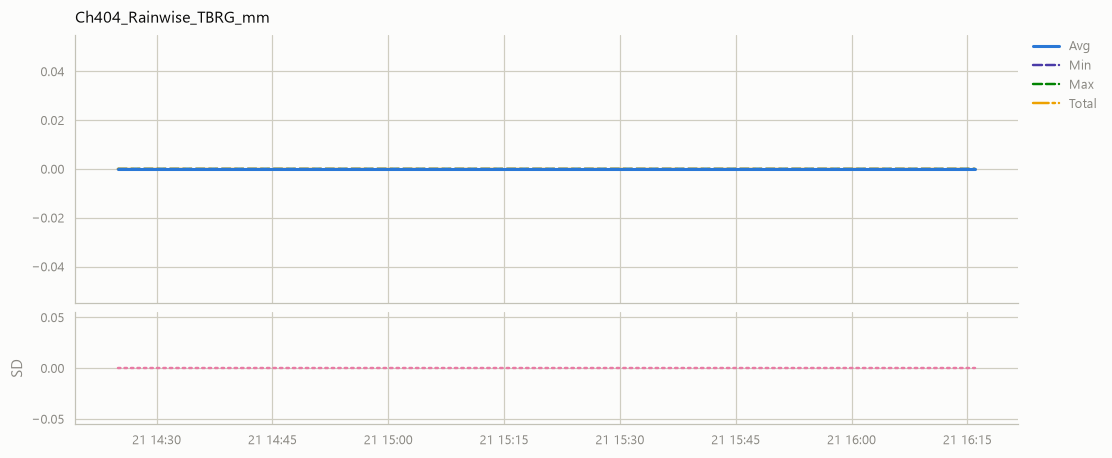

In [32]:
plot_signals(df)